In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../scripts')

In [3]:
import scanpy as sc
import squidpy as sq

import numpy as np
import pandas as pd

/data/a330d/miniforge3/envs/spatial-prop/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


# Data loading

In [4]:
adata = sc.read(
    "/data2/a330d/datasets/cosmx/crc_wt_cosmx/crc_202.h5ad",
    backup_url="https://zenodo.org/records/15574384/files/242.h5ad?download=1"
)
# adata.obsm = {} # NOTE: only some strange PCA embeddings are stored in obsm, which we don't need
adata.obs_names_make_unique()

label_to_coarse = {
    "epi1": "Epithelial",
    "epi2": "Epithelial",
    "epi3": "Epithelial",
    "epi4": "Epithelial",
    
    "fib1": "Fibroblast",
    "fib2": "Fibroblast",
    
    "EC": "Endothelial",
    "SMC": "Smooth_muscle",
    
    "BC": "B_cell",
    "PC_IgA": "Plasma_cell",
    "PC_IgG": "Plasma_cell",
    "PC_IgM": "Plasma_cell",
    
    "TC": "T_cell",
    
    "mye1": "Myeloid",
    "mye2": "Myeloid",
    
    "mast": "Mast_cell",
}

adata.obs["coarse_type"] = adata.obs['ist'].map(label_to_coarse)
labels_key = 'coarse_type'
domains_key = 'typ'
batch_key = 'sid'
adata = adata[~adata.obs[domains_key].isna()] # NOTE: Interesting to annotate?
adata = adata[~adata.obs[labels_key].isna()]

sc.pp.filter_cells(adata, min_counts=3)
sc.pp.filter_genes(adata, min_counts=3)

/data/a330d/miniforge3/envs/spatial-prop/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:174: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number
/data/a330d/miniforge3/envs/spatial-prop/lib/python3.10/contextlib.py:142: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  next(self.gen)


In [5]:
adata.obs[labels_key] = adata.obs[labels_key].astype('category')
adata.obsm['spatial'] = adata.obs[['CenterX_global_px', 'CenterY_global_px']].values
adata.layers['counts'] = adata.X.copy()
sc.pp.highly_variable_genes(adata, layer='counts', flavor='seurat_v3', n_top_genes=2000, subset=True)

In [6]:
x = 0.05  # fraction of cells to keep (e.g., 20%)

n_cells = adata.n_obs
n_subsample = int(n_cells * x)

# Randomly choose cell indices
np.random.seed(42)  # for reproducibility
subsample_idx = np.random.choice(n_cells, n_subsample, replace=False)

# Create the subsampled AnnData
adata = adata[subsample_idx].copy()

## Data splits

In [7]:
split = "ood"

# Get holdout indices
if split == "random":
    fraction = 0.1
    n_cells = adata.n_obs
    n_holdout = int(n_cells * fraction)

    # Randomly choose cells
    test_idx = np.random.choice(n_cells, n_holdout, replace=False)

elif split == "ood":
    holdout_celltype = ["Fibroblast"]
    # OOD: Non-ref, non-epithelial
    #is_tumor_region  = adata.obs["typ"].str.contains("CRC|TVA", regex=True)
    is_tumor_region  = adata.obs["typ"].str.contains("CRC", regex=True)
    #is_holdout_ct = adata.obs["coarse_type"].isin(holdout_celltype)
    is_holdout_ct = adata.obs['coarse_type']!="Epithelial"

    # Combine for test set
    test_mask = (is_tumor_region) & (is_holdout_ct)
    test_idx = np.where(test_mask)[0]
else:
    raise ValueError(f"Unknown split: {split}")

# Get train/val indices
all_idx = np.arange(adata.n_obs)
trainval_idx = np.setdiff1d(all_idx, test_idx)

In [8]:
from sklearn.model_selection import train_test_split

validation_size = 0.1
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=validation_size,
    random_state=0,
    shuffle=True,
)

In [9]:
# Set 'is_holdout' to False by default, then True for selected cells
adata.obs['is_holdout'] = False
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [10]:
adata.obs['data_split'] = 'train'
adata.obs.iloc[val_idx, adata.obs.columns.get_loc('data_split')] = 'valid'
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('data_split')] = 'ood'

In [11]:
adata

AnnData object with n_obs × n_vars = 21034 × 2000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile_

# Train

In [12]:
from simvi.model import SimVI

Global seed set to 0


In [13]:
batch_key = 'sid'

In [14]:
SimVI.setup_anndata(adata, batch_key=batch_key)

/data/a330d/miniforge3/envs/spatial-prop/lib/python3.10/site-packages/scvi/data/_utils.py:102: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


In [15]:
n_neighbors = 3
edge_index = SimVI.extract_edge_index(adata, n_neighbors=n_neighbors, batch_key=batch_key)

In [16]:
from pytorch_lightning.utilities.seed import seed_everything
seed_everything(0)

Global seed set to 0


0

In [17]:
model = SimVI(adata,
              kl_weight=1,
              kl_gatweight=0.01,
              lam_mi=1000,
              permutation_rate=0.5,
              n_spatial=20,
              n_intrinsic=20)
train_loss, val_loss = model.train(edge_index,
                                    max_epochs=4,
                                    batch_size=256,
                                    use_gpu=True,
                                    mae_epochs=3,
                                    device='cuda:1')

Epoch 4/4: 100%|██████████| 4/4 [00:31<00:00,  7.82s/it, train_loss=455, val_loss=451]


In [18]:
adata.obsm['simvi_z'] = model.get_latent_representation(edge_index, representation_kind='intrinsic', give_mean=True)
adata.obsm['simvi_s'] = model.get_latent_representation(edge_index, representation_kind='interaction', give_mean=True)

In [21]:
sc.pp.neighbors(adata, use_rep='simvi_z')
sc.tl.umap(adata)

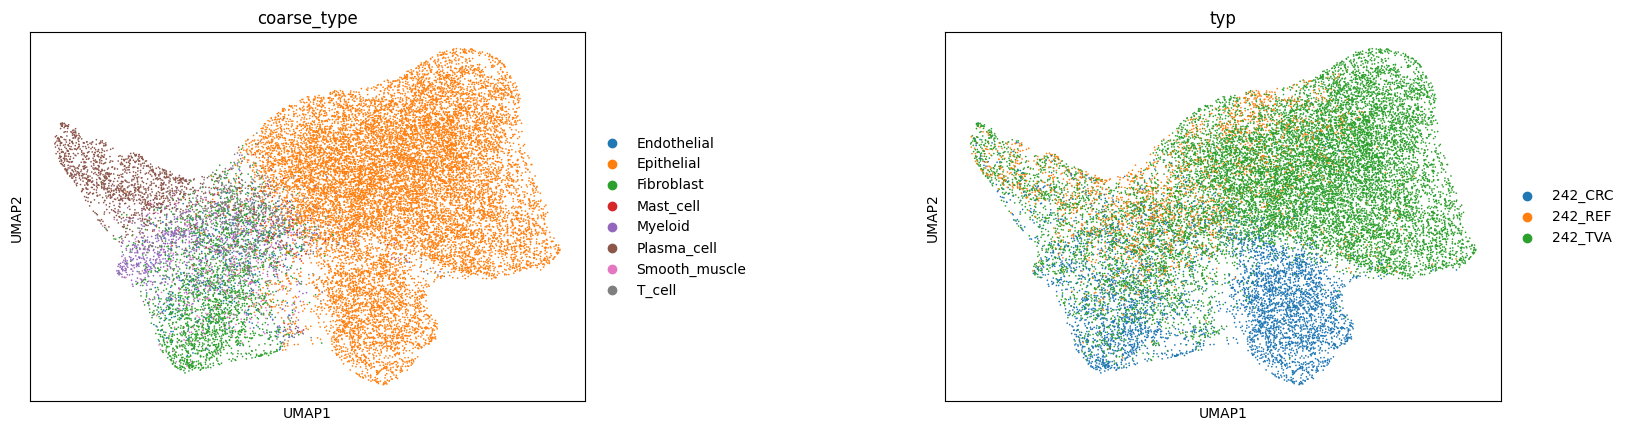

In [22]:
sc.pl.umap(adata, color=['coarse_type','typ'], cmap='Oranges', vmax='p99.5', wspace=0.5)

In [23]:
sc.pp.neighbors(adata, use_rep='simvi_s')
sc.tl.umap(adata)

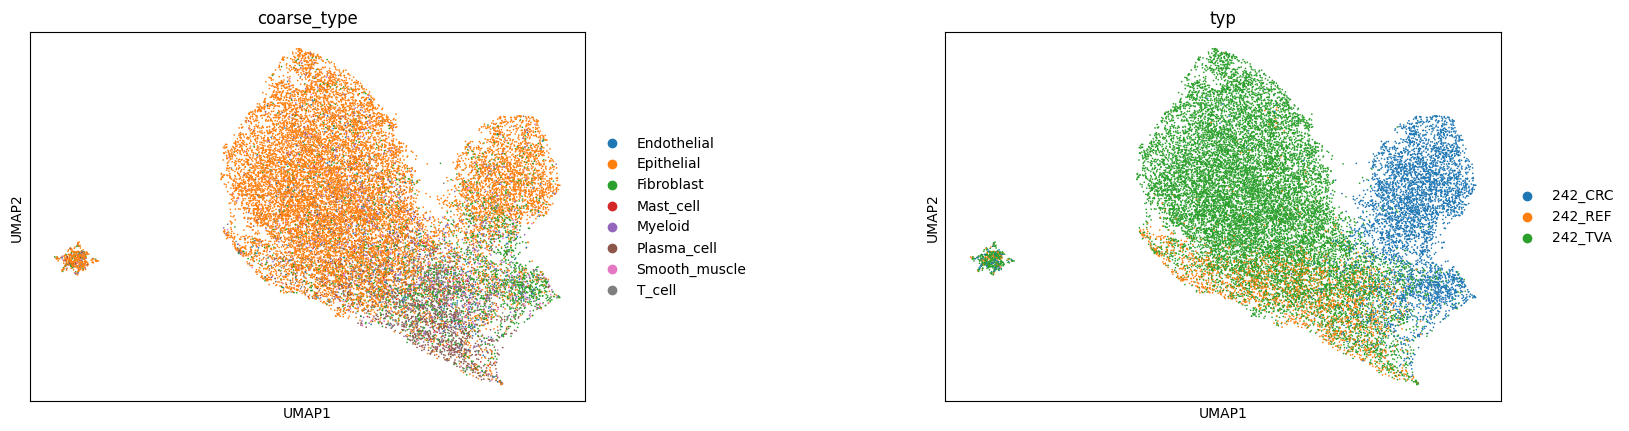

In [24]:
sc.pl.umap(adata, color=['coarse_type','typ'], cmap='Oranges', vmax='p99.5', wspace=0.5)